# Exploratory Data Analysis
## AI Customer Sentiment Analytics Platform

**Author:** Rajat Saini  
**Dataset 1:** Twitter US Airline Sentiment  
**Dataset 2:** Amazon Product Reviews  
**Purpose:** Understand data distribution, quality, and characteristics before modeling

In [7]:
# Standard library
import os
import re
import bz2
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Text analysis
from collections import Counter

# Display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

# Plot styling
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print(" All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

 All libraries imported successfully
Pandas version: 2.2.3
NumPy version: 1.26.4


In [8]:
DATA_RAW = "../../ml/data/raw"

twitter_df = pd.read_csv(f"{DATA_RAW}/Tweets.csv")

print(f"Twitter dataset loaded")
print(f"Shape: {twitter_df.shape}")
print(f"Rows: {twitter_df.shape[0]:,}")
print(f"Columns: {twitter_df.shape[1]}")

Twitter dataset loaded
Shape: (14640, 15)
Rows: 14,640
Columns: 15


In [9]:
print("=== First 5 rows ===")
twitter_df.head()


=== First 5 rows ===


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [10]:
print("=== Dataset Info ===")
print(f"Shape: {twitter_df.shape}")
print(f"\n=== Column Names ===")
print(twitter_df.columns.tolist())
print(f"\n=== Data Types ===")
print(twitter_df.dtypes)
print(f"\n=== Missing Values ===")
print(twitter_df.isnull().sum())

=== Dataset Info ===
Shape: (14640, 15)

=== Column Names ===
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

=== Data Types ===
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

=== Missing Values ===
tweet_i

=== Sentiment Distribution ===
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Percentages:
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


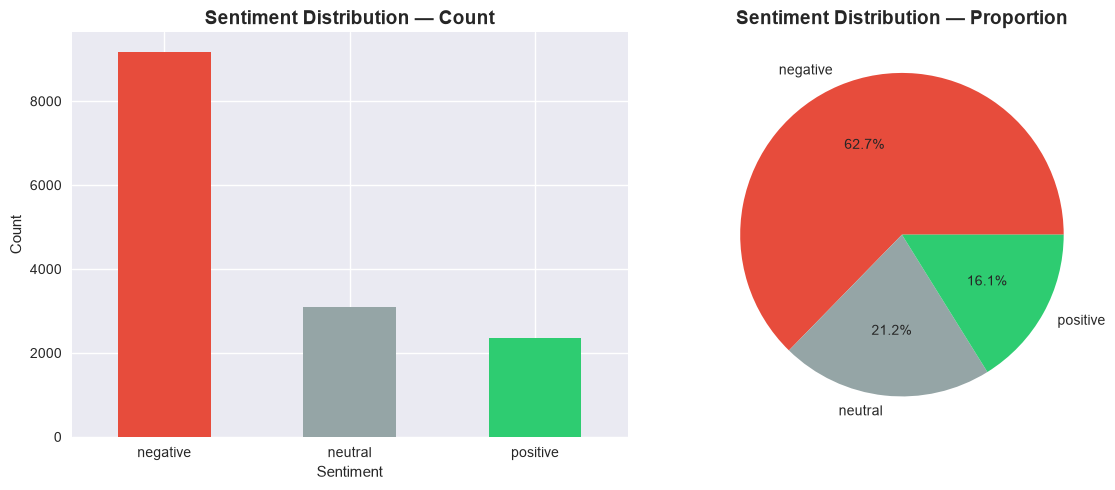

 Chart saved to ml/reports/


In [11]:
print("=== Sentiment Distribution ===")
sentiment_counts = twitter_df["airline_sentiment"].value_counts()
print(sentiment_counts)
print(f"\nPercentages:")
print(twitter_df["airline_sentiment"].value_counts(normalize=True).mul(100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_counts.plot(kind="bar", ax=axes[0], color=["#e74c3c", "#95a5a6", "#2ecc71"])
axes[0].set_title("Sentiment Distribution — Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    colors=["#e74c3c", "#95a5a6", "#2ecc71"]
)
axes[1].set_title("Sentiment Distribution — Proportion", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../../ml/reports/twitter_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Chart saved to ml/reports/")

## Observation: Class Imbalance

The Twitter dataset is **heavily imbalanced**:
- Negative: 62.69%
- Neutral: 21.17%
- Positive: 16.14%

**Why this matters for modeling:**
A naive model that always predicts "negative" would achieve 62.69% accuracy —
which sounds decent but is completely useless. This is why accuracy alone
is not a sufficient metric. We must use **Precision, Recall, and F1-score**
and apply class balancing techniques during training.

**Our solution:**
- Use `class_weight="balanced"` in scikit-learn models
- Evaluate using weighted F1-score as primary metric
- Use confusion matrix to visualize per-class performance

=== Text Length Statistics ===
       text_length  word_count
count     14640.00    14640.00
mean        103.82       17.65
std          36.28        6.88
min          12.00        2.00
25%          77.00       12.00
50%         114.00       19.00
75%         136.00       23.00
max         186.00       36.00


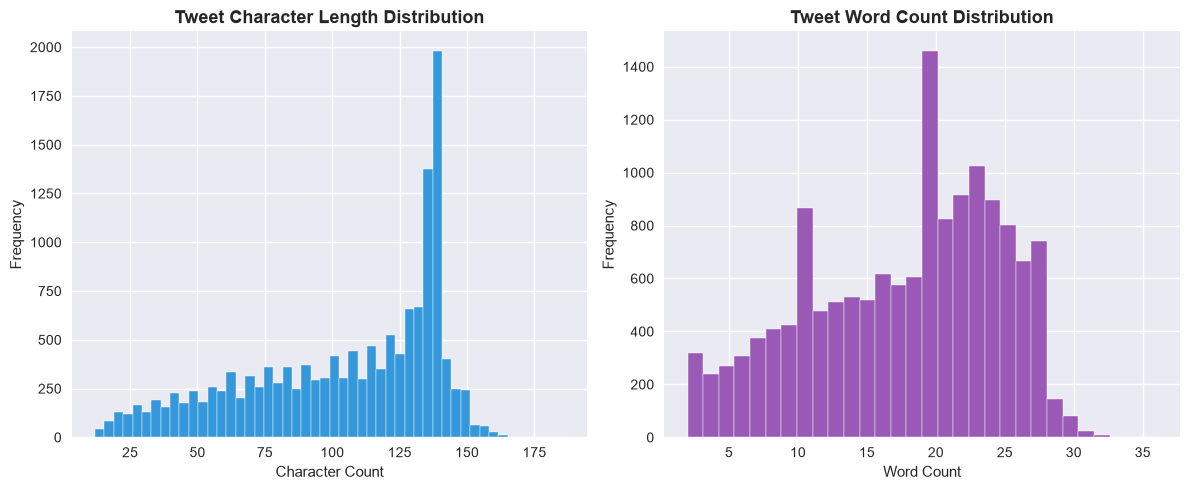

In [12]:
twitter_df["text_length"] = twitter_df["text"].str.len()
twitter_df["word_count"] = twitter_df["text"].str.split().str.len()

print("=== Text Length Statistics ===")
print(twitter_df[["text_length", "word_count"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(twitter_df["text_length"], bins=50, color="#3498db", edgecolor="white")
axes[0].set_title("Tweet Character Length Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(twitter_df["word_count"], bins=30, color="#9b59b6", edgecolor="white")
axes[1].set_title("Tweet Word Count Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../../ml/reports/twitter_text_length.png", dpi=150, bbox_inches="tight")
plt.show()

=== Sentiment % by Airline ===
airline_sentiment  negative  neutral  positive
airline                                       
American              71.04    16.78     12.18
Delta                 42.98    32.54     24.48
Southwest             49.01    27.44     23.55
US Airways            77.69    13.08      9.23
United                68.89    18.24     12.87
Virgin America        35.91    33.93     30.16


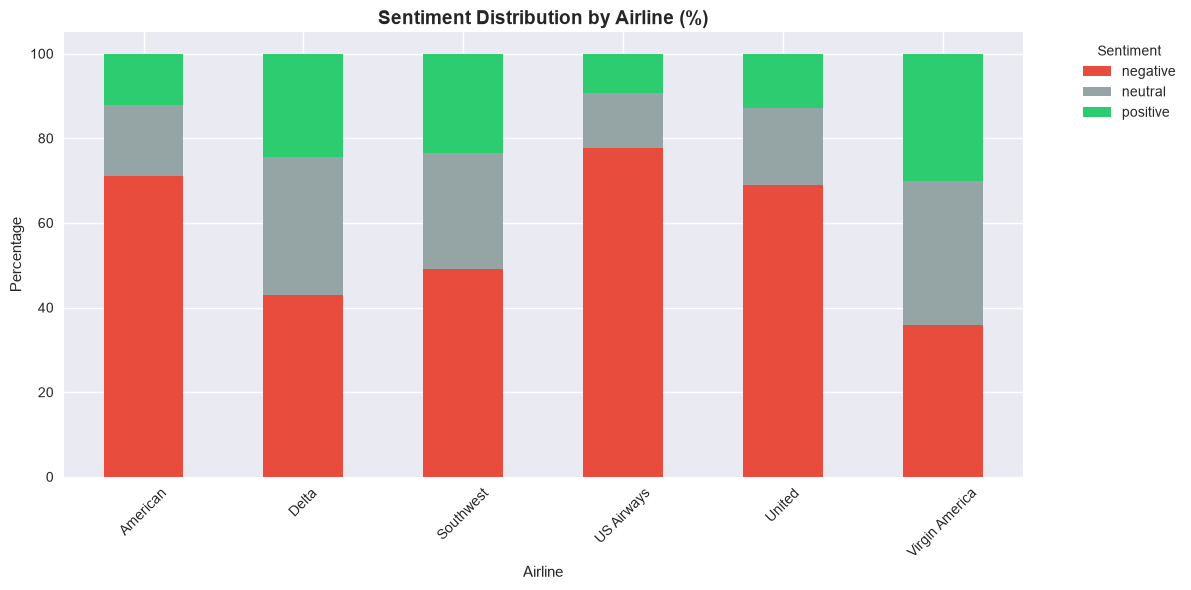

In [13]:
airline_sentiment = twitter_df.groupby(
    ["airline", "airline_sentiment"]
).size().unstack(fill_value=0)

airline_sentiment_pct = airline_sentiment.div(
    airline_sentiment.sum(axis=1), axis=0
).mul(100).round(2)

print("=== Sentiment % by Airline ===")
print(airline_sentiment_pct)

airline_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#e74c3c", "#95a5a6", "#2ecc71"]
)
plt.title("Sentiment Distribution by Airline (%)", fontsize=14, fontweight="bold")
plt.xlabel("Airline")
plt.ylabel("Percentage")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../../ml/reports/twitter_sentiment_by_airline.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
def load_amazon_sample(filepath: str, sample_size: int = 50000) -> pd.DataFrame:
    """
    Load a sample from the Amazon Reviews bz2 file.
    
    The format is: __label__1 or __label__2 followed by review text.
    Label 1 = negative (1-2 stars)
    Label 2 = positive (4-5 stars)
    
    Args:
        filepath: Path to the .ft.txt.bz2 file
        sample_size: Number of rows to sample
    
    Returns:
        DataFrame with 'label' and 'text' columns
    """
    records = []
    with bz2.open(filepath, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_size:
                break
            line = line.strip()
            if line.startswith("__label__"):
                label = int(line[9])
                text = line[11:].strip()
                records.append({"label": label, "text": text})
    
    df = pd.DataFrame(records)
    df["sentiment"] = df["label"].map({1: "negative", 2: "positive"})
    return df


amazon_df = load_amazon_sample(f"{DATA_RAW}/train.ft.txt.bz2", sample_size=50000)

print(f" Amazon dataset loaded")
print(f"Shape: {amazon_df.shape}")
print(f"\nFirst 3 rows:")
print(amazon_df.head(3))
print(f"\nSentiment Distribution:")
print(amazon_df["sentiment"].value_counts())
print(f"\nSentiment %:")
print(amazon_df["sentiment"].value_counts(normalize=True).mul(100).round(2))

 Amazon dataset loaded
Shape: (50000, 3)

First 3 rows:
   label  \
0      2   
1      2   
2      2   

                                                                                                  text  \
0  Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your min...   
1  The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best...   
2  Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of "...   

  sentiment  
0  positive  
1  positive  
2  positive  

Sentiment Distribution:
sentiment
positive    25506
negative    24494
Name: count, dtype: int64

Sentiment %:
sentiment
positive    51.01
negative    48.99
Name: proportion, dtype: float64


## Final EDA Summary

### Twitter Dataset (Primary)
- 14,640 tweets across 6 US airlines
- **Severely imbalanced**: 62.69% negative, 21.17% neutral, 16.14% positive
- Average length: 103 characters, 17 words
- US Airways worst sentiment (77.69% negative)
- Virgin America best sentiment (30.16% positive)
- Zero missing values in `text` and `airline_sentiment` ✅

### Amazon Dataset (Secondary)
- 50,000 samples from 3.6M total reviews
- **Nearly balanced**: 51.01% positive, 48.99% negative
- Binary labels only (no neutral class)
- Much longer texts than tweets

### Decisions for Preprocessing (Step 7)
1. **Class imbalance**: Use `class_weight="balanced"` in all sklearn models
2. **Text cleaning**: Remove @mentions, URLs, hashtags, special characters
3. **Primary metric**: Weighted F1-score (not accuracy)
4. **Tokenization**: Different strategies for short tweets vs long reviews
5. **Feature**: Use only `text` column as input, `airline_sentiment` as target